# PSet 3 - Problem 1 (Fresh MATLAB-aligned implementation)

This notebook rebuilds the two-state income fluctuation problem from scratch, following the MATLAB structure (`start.m`, `valfunc.m`, `ergodic.m`) and using `hetmacro` utilities.

Implemented methods:

1. Grid VFI benchmark
2. Coefficient VFI (cubic spline collocation)
3. Howard improvement algorithm

Key structural feature: collocation nodes are Greville abscissae from `hetmacro.interpolation.greville_abscissae`.

In [ ]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from scipy import sparse
from scipy.sparse import linalg as spla

# Allow running this notebook without installing hetmacro system-wide.
REPO_ROOT = None
for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (p / "hetmacro").exists():
        REPO_ROOT = p
        break
if REPO_ROOT is None:
    raise RuntimeError("Could not locate repository root containing 'hetmacro'.")
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from hetmacro.interpolation import (
    cubic_basis_matrix,
    linear_basis_matrix,
    greville_abscissae,
)
from hetmacro.optimize import golden_max_vec
from hetmacro.forward import stationary_eigenvector

# Directory for figure exports (slides)
TEX_DIR = REPO_ROOT / "examples" / "pset3" / "tex"
TEX_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
class TwoStateModel:
    def __init__(
        self,
        beta=0.95,
        r=0.04,
        sigma=0.10,
        lamb=0.25,
        b=0.25,
        amin=0.0,
        amax=10.0,
        n_breaks=51,
        max_iter_vfi=2000,
        tol_vfi=1e-9,
        max_iter_howard=200,
        tol_howard=1e-9,
        n_howard_warmup=2,
        policy_tol=1e-8,
        c_floor=1e-3,
    ):
        self.beta = float(beta)
        self.r = float(r)
        self.sigma = float(sigma)
        self.lamb = float(lamb)
        self.b = float(b)
        self.amin = float(amin)
        self.amax = float(amax)
        self.n_breaks = int(n_breaks)

        self.max_iter_vfi = int(max_iter_vfi)
        self.tol_vfi = float(tol_vfi)
        self.max_iter_howard = int(max_iter_howard)
        self.tol_howard = float(tol_howard)
        self.n_howard_warmup = int(n_howard_warmup)
        self.policy_tol = float(policy_tol)
        self.c_floor = float(c_floor)

        self.Pi = np.array(
            [[1.0 - self.sigma, self.sigma], [self.lamb, 1.0 - self.lamb]],
            dtype=float,
        )
        self.y = np.array([1.0, self.b], dtype=float)  # [employed, unemployed]

        # MATLAB grid formula for breakpoints.
        u = np.linspace(0.0, 1.0, self.n_breaks)
        self.breakpoints = self.amin + (self.amax - self.amin) * u**2

        # CompEcon-style collocation nodes (Greville abscissae).
        self.a_nodes = greville_abscissae(self.breakpoints, degree=3)
        self.n_basis = self.a_nodes.size

        self.Phi = cubic_basis_matrix(self.breakpoints, self.a_nodes).tocsr()

    @staticmethod
    def _utility(c):
        c = np.asarray(c)
        return np.log(c)

    def _solve_linear(self, A, b):
        if sparse.issparse(A):
            return spla.spsolve(A, b)
        return np.linalg.solve(np.asarray(A), np.asarray(b))

    def _value_rhs_given_c(self, c, a, state, theta_e, theta_u):
        m = (1.0 + self.r) * a + self.y[state]
        a_prime = np.clip(m - c, self.amin, self.amax)
        Phi_prime = cubic_basis_matrix(self.breakpoints, a_prime)
        cont_e = Phi_prime @ theta_e
        cont_u = Phi_prime @ theta_u
        EV = self.Pi[state, 0] * cont_e + self.Pi[state, 1] * cont_u
        return self._utility(c) + self.beta * EV

    def _optimal_c_and_v(self, a, state, theta_e, theta_u, tol=None):
        if tol is None:
            tol = self.policy_tol
        m = (1.0 + self.r) * a + self.y[state]
        lo = np.full_like(a, self.c_floor)
        hi = np.maximum(lo + 1e-12, m)

        def obj(c):
            return self._value_rhs_given_c(c, a, state, theta_e, theta_u)

        c_star, v_star = golden_max_vec(obj, lo, hi, tol=tol)
        return c_star, v_star

    def vfi_step_coeff(self, theta_e, theta_u, policy_tol=None):
        a = self.a_nodes

        c_e, V_e = self._optimal_c_and_v(a, state=0, theta_e=theta_e, theta_u=theta_u, tol=policy_tol)
        c_u, V_u = self._optimal_c_and_v(a, state=1, theta_e=theta_e, theta_u=theta_u, tol=policy_tol)

        theta_e_new = self._solve_linear(self.Phi, V_e)
        theta_u_new = self._solve_linear(self.Phi, V_u)

        err = max(
            np.linalg.norm(theta_e_new - theta_e),
            np.linalg.norm(theta_u_new - theta_u),
        )

        a_e_prime = np.clip((1.0 + self.r) * a + 1.0 - c_e, self.amin, self.amax)
        a_u_prime = np.clip((1.0 + self.r) * a + self.b - c_u, self.amin, self.amax)

        return {
            "theta_e": theta_e_new,
            "theta_u": theta_u_new,
            "c_e": c_e,
            "c_u": c_u,
            "a_e_prime": a_e_prime,
            "a_u_prime": a_u_prime,
            "err": float(err),
        }

    def solve_vfi_coeff(self, max_iter=None, tol=None, policy_tol=None, verbose=True):
        if max_iter is None:
            max_iter = self.max_iter_vfi
        if tol is None:
            tol = self.tol_vfi

        theta_e = np.zeros(self.n_basis)
        theta_u = np.zeros(self.n_basis)

        out = None
        for it in range(1, max_iter + 1):
            out = self.vfi_step_coeff(theta_e, theta_u, policy_tol=policy_tol)
            theta_e = out["theta_e"]
            theta_u = out["theta_u"]
            if verbose and (it <= 10 or it % 25 == 0):
                print(f"Coeff VFI iter {it:4d} | err = {out['err']:.3e}")
            if out["err"] < tol:
                if verbose:
                    print(f"Coeff VFI converged at iter {it} (err={out['err']:.3e})")
                break
        else:
            if verbose:
                print(f"Coeff VFI reached max_iter={max_iter} with err={out['err']:.3e}")

        out["iter"] = it
        out["converged"] = out["err"] < tol
        return out

    def howard_policy_evaluation(self, c_e, c_u):
        a = self.a_nodes
        a_e_prime = np.clip((1.0 + self.r) * a + 1.0 - c_e, self.amin, self.amax)
        a_u_prime = np.clip((1.0 + self.r) * a + self.b - c_u, self.amin, self.amax)

        Phi_e = cubic_basis_matrix(self.breakpoints, a_e_prime).tocsr()
        Phi_u = cubic_basis_matrix(self.breakpoints, a_u_prime).tocsr()

        lhs = sparse.bmat(
            [
                [self.Phi - self.beta * self.Pi[0, 0] * Phi_e, -self.beta * self.Pi[0, 1] * Phi_e],
                [-self.beta * self.Pi[1, 0] * Phi_u, self.Phi - self.beta * self.Pi[1, 1] * Phi_u],
            ],
            format="csr",
        )
        rhs = np.concatenate([self._utility(c_e), self._utility(c_u)])
        theta = self._solve_linear(lhs, rhs)
        nb = self.n_basis
        theta_e_new = theta[:nb]
        theta_u_new = theta[nb:]

        return {
            "theta_e": theta_e_new,
            "theta_u": theta_u_new,
            "a_e_prime": a_e_prime,
            "a_u_prime": a_u_prime,
        }

    def solve_howard(self, n_warmup=None, max_iter=None, tol=None, verbose=True):
        if n_warmup is None:
            n_warmup = self.n_howard_warmup
        if max_iter is None:
            max_iter = self.max_iter_howard
        if tol is None:
            tol = self.tol_howard

        # Warm-up with coefficient VFI steps.
        theta_e = np.zeros(self.n_basis)
        theta_u = np.zeros(self.n_basis)
        c_e = np.full(self.n_basis, self.c_floor)
        c_u = np.full(self.n_basis, self.c_floor)

        for _ in range(n_warmup):
            tmp = self.vfi_step_coeff(theta_e, theta_u)
            theta_e, theta_u = tmp["theta_e"], tmp["theta_u"]
            c_e, c_u = tmp["c_e"], tmp["c_u"]

        out_eval = None
        for it in range(1, max_iter + 1):
            # Policy improvement.
            c_e, _ = self._optimal_c_and_v(self.a_nodes, state=0, theta_e=theta_e, theta_u=theta_u)
            c_u, _ = self._optimal_c_and_v(self.a_nodes, state=1, theta_e=theta_e, theta_u=theta_u)

            # Policy evaluation.
            out_eval = self.howard_policy_evaluation(c_e, c_u)
            theta_e_new = out_eval["theta_e"]
            theta_u_new = out_eval["theta_u"]

            err = max(
                np.linalg.norm(theta_e_new - theta_e),
                np.linalg.norm(theta_u_new - theta_u),
            )

            theta_e, theta_u = theta_e_new, theta_u_new

            if verbose and (it <= 10 or it % 10 == 0):
                print(f"Howard iter {it:4d} | err = {err:.3e}")
            if err < tol:
                if verbose:
                    print(f"Howard converged at iter {it} (err={err:.3e})")
                break
        else:
            if verbose:
                print(f"Howard reached max_iter={max_iter} with err={err:.3e}")

        out = {
            "theta_e": theta_e,
            "theta_u": theta_u,
            "c_e": c_e,
            "c_u": c_u,
            "a_e_prime": out_eval["a_e_prime"],
            "a_u_prime": out_eval["a_u_prime"],
            "err": float(err),
            "iter": it,
            "converged": err < tol,
        }
        return out

    def solve_vfi_grid(self, n_grid=551, max_iter=4000, tol=1e-8, policy_tol=None, verbose=True):
        a = np.linspace(self.amin, self.amax, n_grid)
        V = np.zeros((n_grid, 2))

        a_e_prime = np.zeros(n_grid)
        a_u_prime = np.zeros(n_grid)
        c_e = np.full(n_grid, self.c_floor)
        c_u = np.full(n_grid, self.c_floor)

        if policy_tol is None:
            policy_tol = self.policy_tol

        for it in range(1, max_iter + 1):
            V_new = np.empty_like(V)

            for s in range(2):
                m = (1.0 + self.r) * a + self.y[s]
                lo = np.full_like(a, self.c_floor)
                hi = np.maximum(lo + 1e-12, m)

                def obj(c):
                    a_prime = np.clip(m - c, self.amin, self.amax)
                    Ve_next = np.interp(a_prime, a, V[:, 0])
                    Vu_next = np.interp(a_prime, a, V[:, 1])
                    EV = self.Pi[s, 0] * Ve_next + self.Pi[s, 1] * Vu_next
                    return self._utility(c) + self.beta * EV

                c_star, V_star = golden_max_vec(obj, lo, hi, tol=policy_tol)
                V_new[:, s] = V_star
                a_star = np.clip(m - c_star, self.amin, self.amax)

                if s == 0:
                    c_e, a_e_prime = c_star, a_star
                else:
                    c_u, a_u_prime = c_star, a_star

            err = np.max(np.abs(V_new - V))
            V = V_new

            if verbose and (it <= 10 or it % 50 == 0):
                print(f"Grid VFI  iter {it:4d} | err = {err:.3e}")
            if err < tol:
                if verbose:
                    print(f"Grid VFI converged at iter {it} (err={err:.3e})")
                break
        else:
            if verbose:
                print(f"Grid VFI reached max_iter={max_iter} with err={err:.3e}")

        return {
            "a_grid": a,
            "V": V,
            "c_e": c_e,
            "c_u": c_u,
            "a_e_prime": a_e_prime,
            "a_u_prime": a_u_prime,
            "err": float(err),
            "iter": it,
            "converged": err < tol,
        }

    def evaluate_values_from_theta(self, theta_e, theta_u, a_eval):
        Phi_eval = cubic_basis_matrix(self.breakpoints, np.asarray(a_eval))
        V_e = Phi_eval @ theta_e
        V_u = Phi_eval @ theta_u
        return V_e, V_u

    def compute_ergodic(self, theta_e, theta_u, K=551, policy_tol=None):
        a = np.linspace(self.amin, self.amax, K)
        if policy_tol is None:
            policy_tol = self.policy_tol

        c_e, _ = self._optimal_c_and_v(a, state=0, theta_e=theta_e, theta_u=theta_u, tol=policy_tol)
        c_u, _ = self._optimal_c_and_v(a, state=1, theta_e=theta_e, theta_u=theta_u, tol=policy_tol)

        a_e_prime = np.clip((1.0 + self.r) * a + 1.0 - c_e, self.amin, self.amax)
        a_u_prime = np.clip((1.0 + self.r) * a + self.b - c_u, self.amin, self.amax)

        Phi_e = linear_basis_matrix(a, a_e_prime).tocsr()
        Phi_u = linear_basis_matrix(a, a_u_prime).tocsr()

        Q = sparse.bmat(
            [
                [(1.0 - self.sigma) * Phi_e, self.sigma * Phi_e],
                [self.lamb * Phi_u, (1.0 - self.lamb) * Phi_u],
            ],
            format="csr",
        )

        n = stationary_eigenvector(Q)
        n_e = n[:K]
        n_u = n[K:]

        stationarity_error = np.linalg.norm(n - (Q.T @ n))

        moments = {
            "fraction_employed": float(np.sum(n_e)),
            "mean_assets_employed": float(np.dot(n_e, a) / np.sum(n_e)),
            "mean_assets_unemployed": float(np.dot(n_u, a) / np.sum(n_u)),
            "mean_consumption_employed": float(np.dot(n_e, c_e) / np.sum(n_e)),
            "mean_consumption_unemployed": float(np.dot(n_u, c_u) / np.sum(n_u)),
            "stationarity_error": float(stationarity_error),
        }

        return {
            "a_grid": a,
            "n_e": n_e,
            "n_u": n_u,
            "c_e": c_e,
            "c_u": c_u,
            "a_e_prime": a_e_prime,
            "a_u_prime": a_u_prime,
            "Q": Q,
            "moments": moments,
        }

In [ ]:
m = TwoStateModel(
    beta=0.95,
    r=0.04,
    sigma=0.10,
    lamb=0.25,
    b=0.25,
    amin=0.0,
    amax=10.0,
    n_breaks=51,
    max_iter_vfi=2000,
    tol_vfi=1e-9,
    max_iter_howard=200,
    tol_howard=1e-9,
    n_howard_warmup=2,
    policy_tol=1e-8,
)

print(f"breakpoints: {m.breakpoints.size}, basis/collocation nodes: {m.n_basis}")

res_grid = m.solve_vfi_grid(n_grid=551, max_iter=4000, tol=1e-8, verbose=True)
res_coeff = m.solve_vfi_coeff(max_iter=2000, tol=1e-9, verbose=True)
res_howard = m.solve_howard(max_iter=200, tol=1e-9, verbose=True)

print("\nConvergence summary")
print(
    {
        "grid": {"iter": res_grid["iter"], "err": res_grid["err"], "converged": res_grid["converged"]},
        "coeff": {"iter": res_coeff["iter"], "err": res_coeff["err"], "converged": res_coeff["converged"]},
        "howard": {"iter": res_howard["iter"], "err": res_howard["err"], "converged": res_howard["converged"]},
    }
)

breakpoints: 51, basis/collocation nodes: 53
Grid VFI  iter    1 | err = 2.434e+00
Grid VFI  iter    2 | err = 1.144e+00
Grid VFI  iter    3 | err = 7.343e-01
Grid VFI  iter    4 | err = 5.651e-01
Grid VFI  iter    5 | err = 4.537e-01
Grid VFI  iter    6 | err = 3.774e-01
Grid VFI  iter    7 | err = 3.235e-01
Grid VFI  iter    8 | err = 2.841e-01
Grid VFI  iter    9 | err = 2.542e-01
Grid VFI  iter   10 | err = 2.307e-01
Grid VFI  iter   50 | err = 2.313e-02
Grid VFI  iter  100 | err = 1.756e-03
Grid VFI  iter  150 | err = 1.350e-04
Grid VFI  iter  200 | err = 1.039e-05
Grid VFI  iter  250 | err = 7.994e-07
Grid VFI  iter  300 | err = 6.151e-08
Grid VFI converged at iter 336 (err=9.704e-09)
Coeff VFI iter    1 | err = 1.066e+01
Coeff VFI iter    2 | err = 5.036e+00
Coeff VFI iter    3 | err = 3.629e+00
Coeff VFI iter    4 | err = 2.850e+00
Coeff VFI iter    5 | err = 2.346e+00
Coeff VFI iter    6 | err = 2.002e+00
Coeff VFI iter    7 | err = 1.757e+00
Coeff VFI iter    8 | err = 1.578e

In [ ]:
dist = m.compute_ergodic(res_howard["theta_e"], res_howard["theta_u"], K=551)

print("Ergodic moments")
for k, v in dist["moments"].items():
    print(f"{k:30s}: {v:.6e}")

Ergodic moments
fraction_employed             : 7.142857e-01
mean_assets_employed          : 2.597294e+00
mean_assets_unemployed        : 1.749561e+00
mean_consumption_employed     : 9.734713e-01
mean_consumption_unemployed   : 6.460336e-01
stationarity_error            : 1.330644e-17


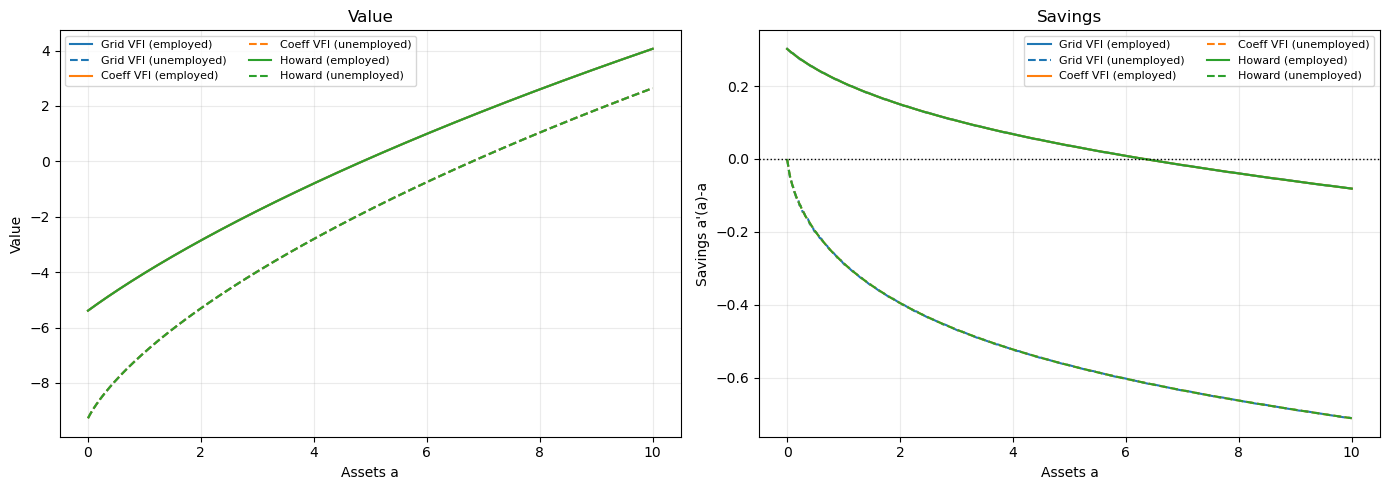

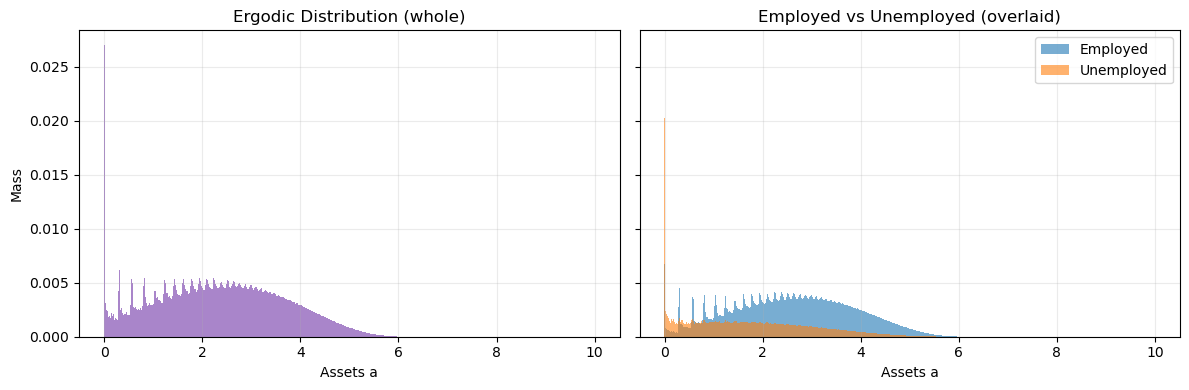

In [ ]:
# Common grid for plotting/comparisons
ap = m.a_nodes
a_dense = res_grid["a_grid"]

# Value functions
Vg_e, Vg_u = res_grid["V"][:, 0], res_grid["V"][:, 1]
Vc_e, Vc_u = m.evaluate_values_from_theta(res_coeff["theta_e"], res_coeff["theta_u"], a_dense)
Vh_e, Vh_u = m.evaluate_values_from_theta(res_howard["theta_e"], res_howard["theta_u"], a_dense)

# Policies (interpolate coeff/howard node policies onto dense grid)
apg_e, apg_u = res_grid["a_e_prime"], res_grid["a_u_prime"]
apc_e = np.interp(a_dense, ap, res_coeff["a_e_prime"])
apc_u = np.interp(a_dense, ap, res_coeff["a_u_prime"])
aph_e = np.interp(a_dense, ap, res_howard["a_e_prime"])
aph_u = np.interp(a_dense, ap, res_howard["a_u_prime"])

# Side-by-side: Value (left) and Savings (right) so you can see if the three methods coincide
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Value functions
ax1.plot(a_dense, Vg_e, color="C0", linestyle="-", label="Grid VFI (employed)")
ax1.plot(a_dense, Vg_u, color="C0", linestyle="--", label="Grid VFI (unemployed)")
ax1.plot(a_dense, Vc_e, color="C1", linestyle="-", label="Coeff VFI (employed)")
ax1.plot(a_dense, Vc_u, color="C1", linestyle="--", label="Coeff VFI (unemployed)")
ax1.plot(a_dense, Vh_e, color="C2", linestyle="-", label="Howard (employed)")
ax1.plot(a_dense, Vh_u, color="C2", linestyle="--", label="Howard (unemployed)")
ax1.set_xlabel("Assets a")
ax1.set_ylabel("Value")
ax1.set_title("Value")
ax1.grid(alpha=0.25)
ax1.legend(ncol=2, fontsize=8)

# Right: Savings a'(a) - a
ax2.plot(a_dense, apg_e - a_dense, color="C0", linestyle="-", label="Grid VFI (employed)")
ax2.plot(a_dense, apg_u - a_dense, color="C0", linestyle="--", label="Grid VFI (unemployed)")
ax2.plot(a_dense, apc_e - a_dense, color="C1", linestyle="-", label="Coeff VFI (employed)")
ax2.plot(a_dense, apc_u - a_dense, color="C1", linestyle="--", label="Coeff VFI (unemployed)")
ax2.plot(a_dense, aph_e - a_dense, color="C2", linestyle="-", label="Howard (employed)")
ax2.plot(a_dense, aph_u - a_dense, color="C2", linestyle="--", label="Howard (unemployed)")
ax2.axhline(0.0, color="k", linestyle=":", linewidth=1.0)
ax2.set_xlabel("Assets a")
ax2.set_ylabel("Savings a'(a)-a")
ax2.set_title("Savings")
ax2.grid(alpha=0.25)
ax2.legend(ncol=2, fontsize=8)

plt.tight_layout()
fig.savefig(TEX_DIR / "fig_p1_value_and_savings.pdf", bbox_inches="tight", dpi=150)
plt.show()

# Figure 3: Ergodic distributions — left: whole (marginal over assets); right: employed vs unemployed overlaid
w = dist["a_grid"][1] - dist["a_grid"][0]
n_total = dist["n_e"] + dist["n_u"]

fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axs[0].bar(dist["a_grid"], n_total, width=w, color="C4", alpha=0.8)
axs[0].set_title("Ergodic Distribution (whole)")
axs[0].set_xlabel("Assets a")
axs[0].set_ylabel("Mass")
axs[0].grid(alpha=0.25)

axs[1].bar(dist["a_grid"], dist["n_e"], width=w, color="C0", alpha=0.6, label="Employed")
axs[1].bar(dist["a_grid"], dist["n_u"], width=w, color="C1", alpha=0.6, label="Unemployed")
axs[1].set_title("Employed vs Unemployed (overlaid)")
axs[1].set_xlabel("Assets a")
axs[1].legend()
axs[1].grid(alpha=0.25)
plt.tight_layout()
fig.savefig(TEX_DIR / "fig_p1_ergodic_dist.pdf", bbox_inches="tight", dpi=150)
plt.show()

In [ ]:
# Diagnostic comparison against grid VFI benchmark
interior = (a_dense >= a_dense[10]) & (a_dense <= a_dense[-11])

val_diff_coeff = np.max(np.abs(Vc_e[interior] - Vg_e[interior]))
val_diff_howard = np.max(np.abs(Vh_e[interior] - Vg_e[interior]))
pol_diff_coeff = np.max(np.abs((apc_e - a_dense)[interior] - (apg_e - a_dense)[interior]))
pol_diff_howard = np.max(np.abs((aph_e - a_dense)[interior] - (apg_e - a_dense)[interior]))

print("Interior max abs differences vs Grid VFI (employed)")
print(f"Value:   coeff={val_diff_coeff:.3e}, howard={val_diff_howard:.3e}")
print(f"Savings: coeff={pol_diff_coeff:.3e}, howard={pol_diff_howard:.3e}")

Interior max abs differences vs Grid VFI (employed)
Value:   coeff=2.186e-04, howard=2.186e-04
Savings: coeff=1.216e-03, howard=1.216e-03
